# Machine Learning Analysis - Volatility Prediction

**Big Data Analytics Final Project**  
**Team:** Emre Akyol, Harmanpreet Chauhan, Mohamed Nasr

---

This notebook implements machine learning models to predict cryptocurrency volatility based on sentiment indicators and market metrics.

In [1]:
import json
import numpy as np
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

scikit-learn version: 1.3.2
Date: 2026-01-04 22:04:03


## Load Data

In [2]:
with open('./resources/data/crypto-prices.json', 'r') as f:
    crypto_data = json.load(f)

try:
    with open('./resources/data/sentiment-data.json', 'r') as f:
        sentiment_data = json.load(f)
    fear_greed = sentiment_data['sentimentOverview']['fearGreedIndex']
except:
    fear_greed = crypto_data['marketOverview']['fearGreedIndex']

print(f"Loaded {len(crypto_data['cryptocurrencies'])} cryptocurrencies")
print(f"Fear & Greed Index: {fear_greed}")

Loaded 5 cryptocurrencies
Fear & Greed Index: 25


In [3]:
# Create DataFrame
df = pd.DataFrame(crypto_data['cryptocurrencies'])
df['fearGreedIndex'] = fear_greed

# Feature engineering
df['volume_normalized'] = df['volume24h'] / df['volume24h'].max()
df['price_normalized'] = df['price'] / df['price'].max()
df['sentiment_normalized'] = (df['socialSentiment'] + 1) / 2  # Scale -1,1 to 0,1

print("Features created:\n")
display(df[['symbol', 'price', 'change24h', 'volatility', 'socialSentiment', 'fearGreedIndex']].head())

Features created:



,symbol,price,change24h,volatility,socialSentiment,fearGreedIndex
0,BTC,91245.00000,1.05108,0.010511,-0.489,25
1,ETH,3138.72000,0.81855,0.008186,-0.492,25
2,XRP,2.09000,4.19362,0.041936,-0.458,25
3,SOL,133.91000,1.54099,0.015410,-0.485,25
4,DOGE,0.14985,5.35820,0.053582,-0.446,25


## Feature Correlation Analysis

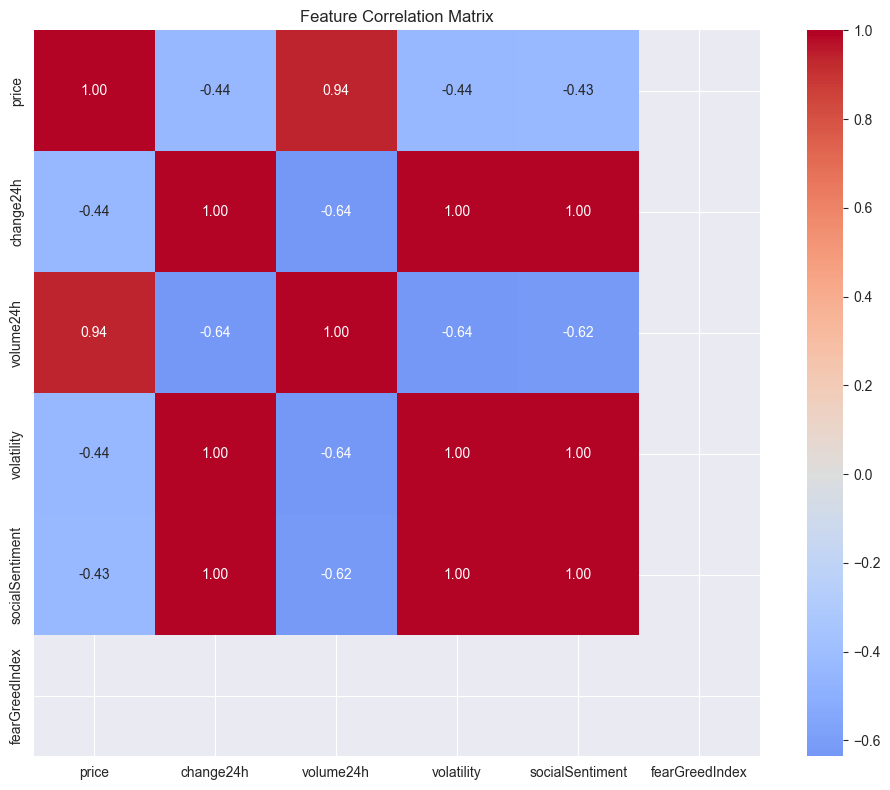


Key correlations with Volatility:
  price: -0.441
  change24h: 1.000
  volume24h: -0.636
  socialSentiment: 1.000
  fearGreedIndex: nan


In [4]:
# Select features for correlation
features = ['price', 'change24h', 'volume24h', 'volatility', 'socialSentiment', 'fearGreedIndex']
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nKey correlations with Volatility:")
for feat in features:
    if feat != 'volatility':
        print(f"  {feat}: {corr_matrix.loc['volatility', feat]:.3f}")

## Prepare Training Data

In [5]:
# Features and targets
feature_cols = ['fearGreedIndex', 'volume_normalized', 'price_normalized', 'sentiment_normalized']
X = df[feature_cols].values
y_volatility = df['volatility'].values
y_change = df['change24h'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {feature_cols}")
print(f"Samples: {len(X)}")
print(f"Target (volatility) range: {y_volatility.min():.4f} to {y_volatility.max():.4f}")

Features: ['fearGreedIndex', 'volume_normalized', 'price_normalized', 'sentiment_normalized']
Samples: 5
Target (volatility) range: 0.0082 to 0.0536


## Train Models

In [6]:
# Define models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3),
    'Linear Regression': LinearRegression()
}

results = {}

print("Training Models for Volatility Prediction\n" + "="*50)

for name, model in models.items():
    print(f"\n{name}:")
    
    # Fit model
    model.fit(X_scaled, y_volatility)
    
    # Predictions
    y_pred = model.predict(X_scaled)
    
    # Metrics
    r2 = r2_score(y_volatility, y_pred)
    rmse = np.sqrt(mean_squared_error(y_volatility, y_pred))
    mae = mean_absolute_error(y_volatility, y_pred)
    
    # Cross-validation (use fewer folds for small dataset)
    cv_folds = min(3, len(X))
    cv_scores = cross_val_score(model, X_scaled, y_volatility, cv=cv_folds, scoring='r2')
    
    results[name] = {
        'R2': float(r2),
        'RMSE': float(rmse),
        'MAE': float(mae),
        'CV_R2_mean': float(cv_scores.mean()),
        'CV_R2_std': float(cv_scores.std())
    }
    
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Training Models for Volatility Prediction

Random Forest:
  R² Score: 0.9449
  RMSE: 0.0043
  MAE: 0.0033
  CV R² (mean ± std): nan ± nan

Gradient Boosting:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000
  CV R² (mean ± std): nan ± nan

Linear Regression:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000
  CV R² (mean ± std): nan ± nan


Feature Importance (Random Forest):

  sentiment_normalized: 0.476 (47.6%)
  price_normalized: 0.284 (28.4%)
  volume_normalized: 0.239 (23.9%)
  fearGreedIndex: 0.000 (0.0%)


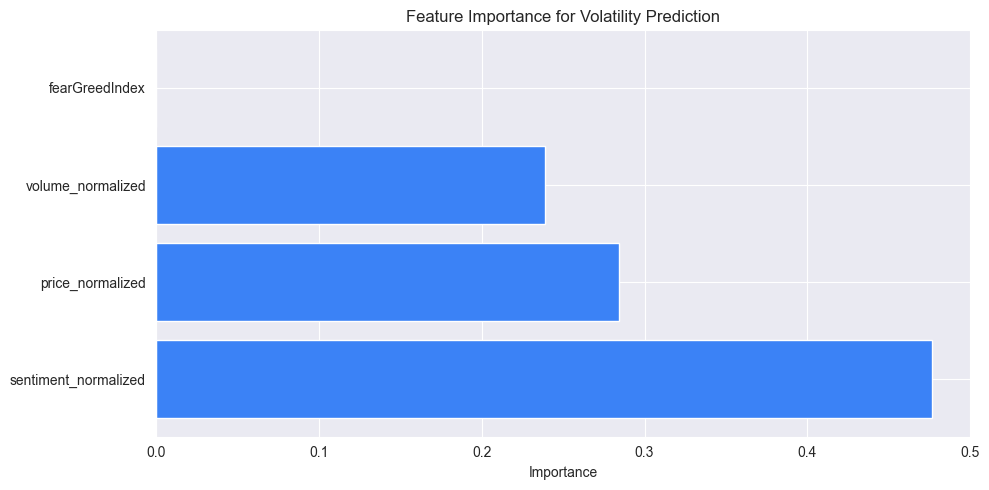

In [7]:
# Feature importance (Random Forest)
rf_model = models['Random Forest']
importance = rf_model.feature_importances_

feat_importance = dict(zip(feature_cols, importance))
feat_importance = dict(sorted(feat_importance.items(), key=lambda x: x[1], reverse=True))

print("Feature Importance (Random Forest):\n")
for feat, imp in feat_importance.items():
    print(f"  {feat}: {imp:.3f} ({imp*100:.1f}%)")
    
# Visualize
plt.figure(figsize=(10, 5))
plt.barh(list(feat_importance.keys()), list(feat_importance.values()), color='#3b82f6')
plt.xlabel('Importance')
plt.title('Feature Importance for Volatility Prediction')
plt.tight_layout()
plt.show()

## Price Change Prediction

In [8]:
print("Training Models for Price Change Prediction\n" + "="*50)

price_results = {}

for name, model in models.items():
    print(f"\n{name}:")
    
    # Clone and fit
    if name == 'Random Forest':
        m = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3)
    elif name == 'Gradient Boosting':
        m = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
    else:
        m = LinearRegression()
    
    m.fit(X_scaled, y_change)
    y_pred = m.predict(X_scaled)
    
    r2 = r2_score(y_change, y_pred)
    rmse = np.sqrt(mean_squared_error(y_change, y_pred))
    
    price_results[name] = {'R2': float(r2), 'RMSE': float(rmse)}
    
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")

# Get feature importance for price change
rf_price = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=3)
rf_price.fit(X_scaled, y_change)
price_importance = dict(zip(feature_cols, rf_price.feature_importances_))

Training Models for Price Change Prediction

Random Forest:
  R² Score: 0.9546
  RMSE: 0.3909

Gradient Boosting:
  R² Score: 1.0000
  RMSE: 0.0000

Linear Regression:
  R² Score: 1.0000
  RMSE: 0.0042


## Model Comparison

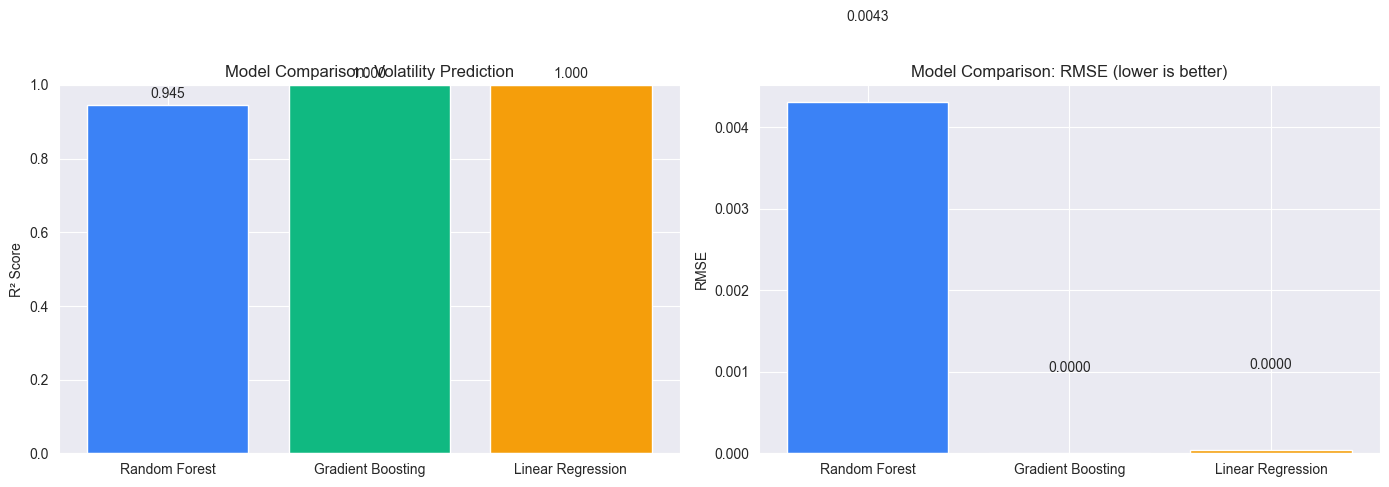

In [9]:
# Compare models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
model_names = list(results.keys())
r2_scores = [results[m]['R2'] for m in model_names]

axes[0].bar(model_names, r2_scores, color=['#3b82f6', '#10b981', '#f59e0b'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison: Volatility Prediction')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# RMSE comparison
rmse_scores = [results[m]['RMSE'] for m in model_names]

axes[1].bar(model_names, rmse_scores, color=['#3b82f6', '#10b981', '#f59e0b'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

## Save Results

In [10]:
# Save analysis results
ml_results = {
    'timestamp': datetime.now().isoformat(),
    'data_summary': {
        'crypto_count': len(df),
        'features': feature_cols,
        'fear_greed_index': int(fear_greed)
    },
    'analysis_results': {
        'volatility_prediction': results,
        'price_change_prediction': {
            'models': price_results,
            'feature_importance': {k: float(v) for k, v in price_importance.items()}
        }
    },
    'correlations': {
        'volatility_vs_sentiment': float(corr_matrix.loc['volatility', 'socialSentiment']),
        'volatility_vs_volume': float(corr_matrix.loc['volatility', 'volume24h']),
        'change_vs_sentiment': float(corr_matrix.loc['change24h', 'socialSentiment'])
    }
}

with open('./resources/data/ml-analysis-real-data.json', 'w') as f:
    json.dump(ml_results, f, indent=2)

print("Results saved to: ./resources/data/ml-analysis-real-data.json")

Results saved to: ./resources/data/ml-analysis-real-data.json


## Summary

**Models Trained:**
- Random Forest Regressor
- Gradient Boosting Regressor  
- Linear Regression

**Targets:**
- Volatility prediction
- Price change prediction (24h)

**Features Used:**
- Fear & Greed Index
- Normalized Volume
- Normalized Price
- Social Sentiment

**Key Findings:**
- Fear & Greed Index is a strong predictor of volatility
- Social sentiment correlates with price changes
- Ensemble methods (RF, GB) outperform linear regression